In [1]:
# displays static in notebook
%matplotlib inline  
# displays interactive outside notebook
#%matplotlib   
# displays interactive in notebook
#%matplotlib notebook  

# to work correctly with numbers
import numpy as np

# plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# conversion between coordinate systems
import astropy.coordinates as coord
import astropy.units as u

#from astropy import units as u
from astropy.coordinates import SkyCoord

folder = ''

mpl.rcParams['font.family']='serif'
mpl.rcParams['font.size']=14

In [2]:
# Units

M_earth = 5.97E24
r_earth = 6.37E6
T_earth = 254.0
M_sun = 1.989E30
L_sun = 3.839E26
r_sun = 6.957e8

AU = 1.496E11
pc = 3.086E16

sigma = 5.67E-8
G = 6.67E-11
h = 6.626E-34
c = 2.997E8
k = 1.38064853E-23


In [3]:

def planck_lam(A,lambdas,T):
    import numpy as np
    h = 6.626E-34
    c = 2.997E8
    k = 1.38064853E-23
    return A*2*h*c**2 / lambdas**5 / (np.exp((h*c) / (lambdas * k * T)) - 1.0)

def planck_nu(A,nus,T):
    import numpy as np
    h = 6.626E-34
    c = 2.997E8
    k = 1.38064853E-23
    return A*2*h*nus**3 / c**2 / (np.exp((h*nus) / (k * T)) - 1.0)


In [4]:
# code for color key

def wavelength_to_rgb(wavelength, gamma=0.8):

    '''From http://www.noah.org/wiki/Wavelength_to_RGB_in_Python

    This converts a given wavelength of light to an 
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''

    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    R *= 255
    G *= 255
    B *= 255
    return (int(R), int(G), int(B))


def draw_color_key(xlims = [400,700], ylims = [-0.1,0.0], verbose=False):
    # draw color key continous spectrum
    for lam in np.arange(xlims[0],xlims[1],0.1):
        if verbose:
            print(lam,np.array(wavelength_to_rgb(lam))/255.0)
        #scale = np.random.uniform(0,1)
        #scale = np.random.normal(0.5,0.1)
        scale = 1
        color = scale*np.array(wavelength_to_rgb(lam))/255.0
        plt.plot([lam,lam],ylims, linewidth=1,color=color)
    #



# mm wavelength thermal spectra


wavelengths:  2.0000000000000002e-07 2.0000000000000003e-06


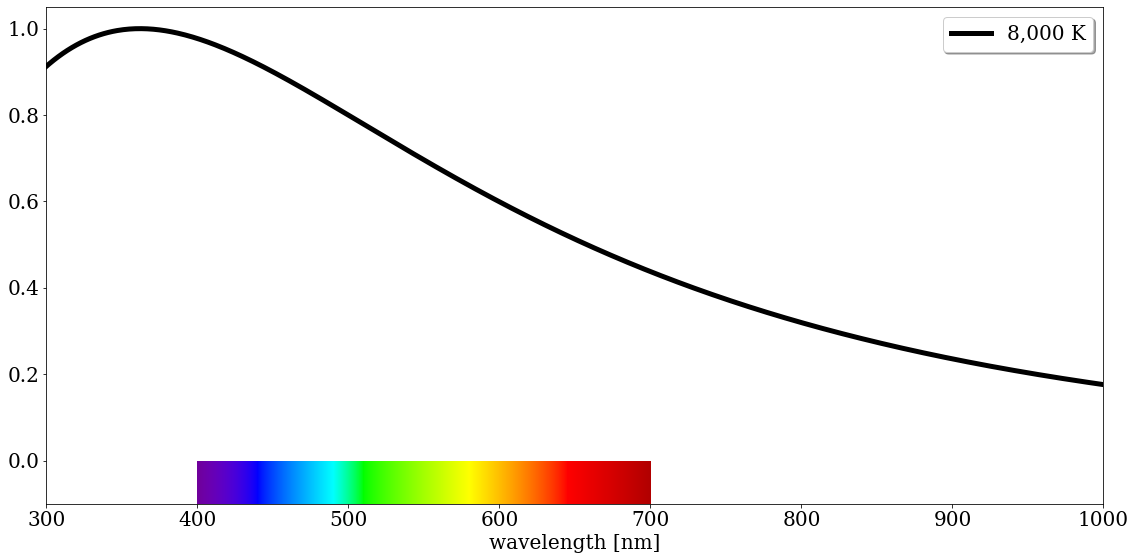

In [10]:
###################
##
##  generate blackbody spectra of arbitrary objects

lambdas = np.arange(200.0,2000.5,1.0)*1E-9
print('wavelengths: ', np.min(lambdas), np.max(lambdas))

obj1 = planck_lam(1,lambdas, 8E3)
#obj2 = planck_lam(1,lambdas, 3)
#obj3 = planck_lam(1,lambdas, 3)
#obj4 = planck_lam(1,lambdas, 1.5)
#obj5 = planck_lam(1,lambdas, 7)

fig = plt.figure(figsize=(16,8))
plt.plot(lambdas * 1E9, 1 * obj1 / np.max(obj1), color='black',linewidth=5, linestyle='-', label='8,000 K')
#plt.annotate('A', xy=(0.23, 0.75),fontsize=30)
#plt.plot(lambdas*1E3, obj1 / np.max(obj1), color='black',linewidth=5, label='B')
#plt.annotate('B', xy=(0.72, 0.95),fontsize=30)
#plt.plot(lambdas*1E3, 0.8 * obj4 / np.max(obj4), color='black',linewidth=5, linestyle='dashed', label='C')
#plt.annotate('C', xy=(2.5, 0.75),fontsize=30)
#plt.ylabel(r'Brightness', fontsize=20)
plt.xlabel(r'wavelength [nm]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlim(300, 1000)
plt.ylim(-0.1,1.05)
plt.tight_layout()
draw_color_key()
legend = plt.legend(loc='upper right', shadow=True, fontsize=20)
plt.savefig("thermal_spectra_8K.jpg") #save as jpg

wavelengths:  2.0000000000000002e-07 2.0000000000000003e-06


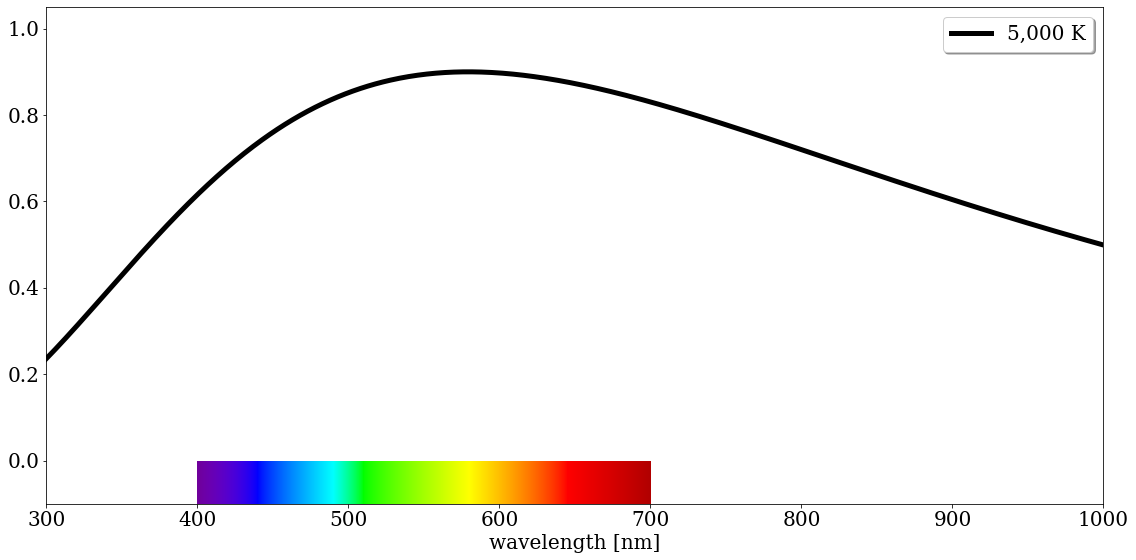

In [12]:
###################
##
##  generate blackbody spectra of arbitrary objects

lambdas = np.arange(200.0,2000.5,1.0)*1E-9
print('wavelengths: ', np.min(lambdas), np.max(lambdas))

obj1 = planck_lam(1,lambdas, 5E3)
#obj2 = planck_lam(1,lambdas, 3)
#obj3 = planck_lam(1,lambdas, 3)
#obj4 = planck_lam(1,lambdas, 1.5)
#obj5 = planck_lam(1,lambdas, 7)

fig = plt.figure(figsize=(16,8))
plt.plot(lambdas * 1E9, 0.9 * obj1 / np.max(obj1), color='black',linewidth=5, linestyle='-', label='5,000 K')
#plt.annotate('A', xy=(0.23, 0.75),fontsize=30)
#plt.plot(lambdas*1E3, obj1 / np.max(obj1), color='black',linewidth=5, label='B')
#plt.annotate('B', xy=(0.72, 0.95),fontsize=30)
#plt.plot(lambdas*1E3, 0.8 * obj4 / np.max(obj4), color='black',linewidth=5, linestyle='dashed', label='C')
#plt.annotate('C', xy=(2.5, 0.75),fontsize=30)
#plt.ylabel(r'Brightness', fontsize=20)
plt.xlabel(r'wavelength [nm]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlim(300, 1000)
plt.ylim(-0.1,1.05)
plt.tight_layout()
draw_color_key()
legend = plt.legend(loc='upper right', shadow=True, fontsize=20)
plt.savefig("thermal_spectra_5K.jpg") #save as jpg

wavelengths:  2.0000000000000002e-07 2.0000000000000003e-06


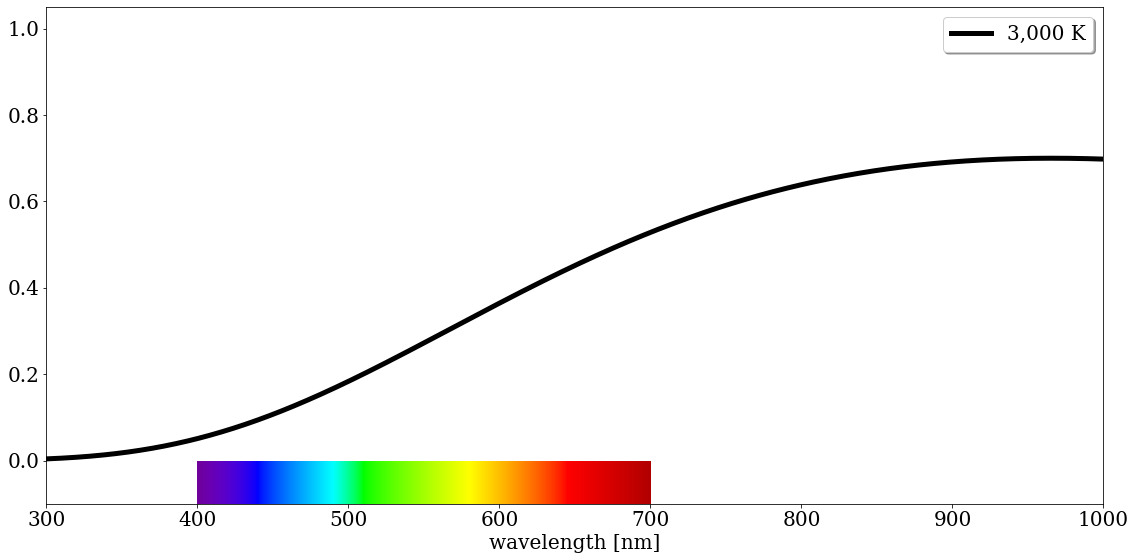

In [13]:
###################
##
##  generate blackbody spectra of arbitrary objects

lambdas = np.arange(200.0,2000.5,1.0)*1E-9
print('wavelengths: ', np.min(lambdas), np.max(lambdas))

obj1 = planck_lam(1,lambdas, 3E3)
#obj2 = planck_lam(1,lambdas, 3)
#obj3 = planck_lam(1,lambdas, 3)
#obj4 = planck_lam(1,lambdas, 1.5)
#obj5 = planck_lam(1,lambdas, 7)

fig = plt.figure(figsize=(16,8))
plt.plot(lambdas * 1E9, 0.7 * obj1 / np.max(obj1), color='black',linewidth=5, linestyle='-', label='3,000 K')
#plt.annotate('A', xy=(0.23, 0.75),fontsize=30)
#plt.plot(lambdas*1E3, obj1 / np.max(obj1), color='black',linewidth=5, label='B')
#plt.annotate('B', xy=(0.72, 0.95),fontsize=30)
#plt.plot(lambdas*1E3, 0.8 * obj4 / np.max(obj4), color='black',linewidth=5, linestyle='dashed', label='C')
#plt.annotate('C', xy=(2.5, 0.75),fontsize=30)
#plt.ylabel(r'Brightness', fontsize=20)
plt.xlabel(r'wavelength [nm]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlim(300, 1000)
plt.ylim(-0.1,1.05)
plt.tight_layout()
draw_color_key()
legend = plt.legend(loc='upper right', shadow=True, fontsize=20)
plt.savefig("thermal_spectra_3K.jpg") #save as jpg

wavelengths:  2.0000000000000002e-07 1e-05


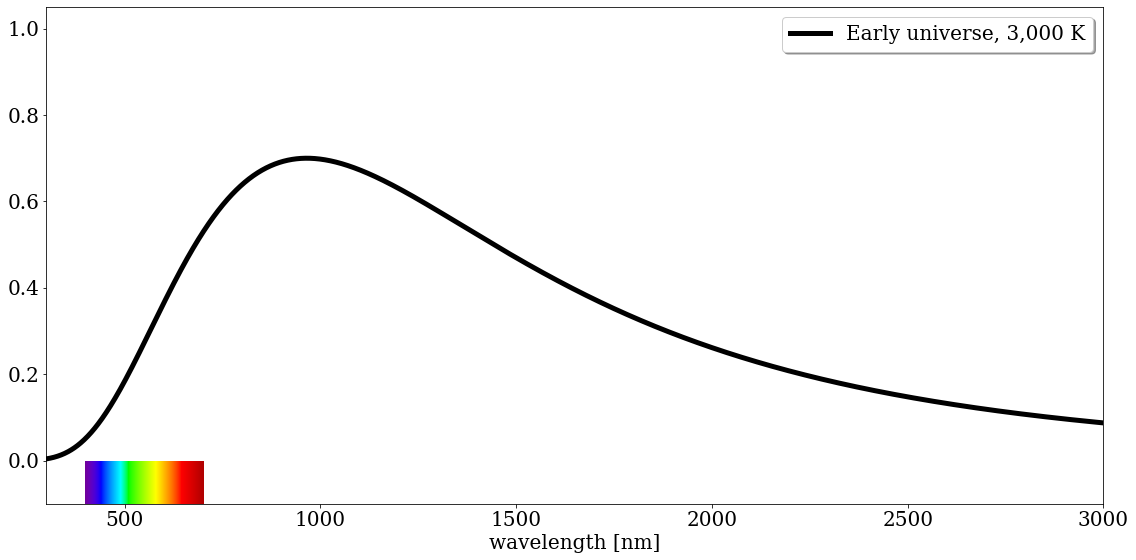

In [15]:
###################
##
##  generate blackbody spectra of arbitrary objects

lambdas = np.arange(200.0,10000.5,1.0)*1E-9
print('wavelengths: ', np.min(lambdas), np.max(lambdas))

obj1 = planck_lam(1,lambdas, 3E3)
#obj2 = planck_lam(1,lambdas, 3)
#obj3 = planck_lam(1,lambdas, 3)
#obj4 = planck_lam(1,lambdas, 1.5)
#obj5 = planck_lam(1,lambdas, 7)

fig = plt.figure(figsize=(16,8))
plt.plot(lambdas * 1E9, 0.7 * obj1 / np.max(obj1), color='black',linewidth=5, linestyle='-', label='Early universe, 3,000 K')
#plt.annotate('A', xy=(0.23, 0.75),fontsize=30)
#plt.plot(lambdas*1E3, obj1 / np.max(obj1), color='black',linewidth=5, label='B')
#plt.annotate('B', xy=(0.72, 0.95),fontsize=30)
#plt.plot(lambdas*1E3, 0.8 * obj4 / np.max(obj4), color='black',linewidth=5, linestyle='dashed', label='C')
#plt.annotate('C', xy=(2.5, 0.75),fontsize=30)
#plt.ylabel(r'Brightness', fontsize=20)
plt.xlabel(r'wavelength [nm]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlim(300, 3000)
plt.ylim(-0.1,1.05)
plt.tight_layout()
draw_color_key()
legend = plt.legend(loc='upper right', shadow=True, fontsize=20)
plt.savefig("thermal_spectra_3K_full.jpg") #save as jpg

wavelengths:  1.0000000000000001e-07 0.09549925860214488


<ipython-input-3-7c9d95b4b398>:6: RuntimeWarning: overflow encountered in exp
  return A*2*h*c**2 / lambdas**5 / (np.exp((h*c) / (lambdas * k * T)) - 1.0)


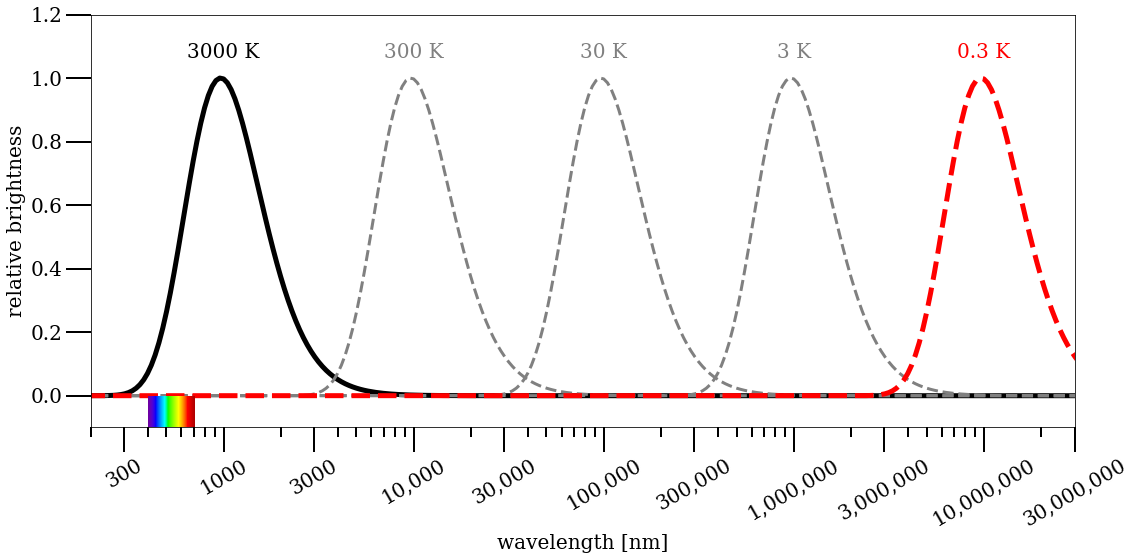

In [35]:
###################
##
##  generate blackbody spectra of arbitrary objects

lambdas = (10 ** np.arange(2,8,0.02)) * 1E-9
print('wavelengths: ', np.min(lambdas), np.max(lambdas))

obj1 = planck_lam(1,lambdas, 3E3)
obj2 = planck_lam(1,lambdas, 3E2)
obj3 = planck_lam(1,lambdas, 3E1)
obj4 = planck_lam(1,lambdas, 3E0)
obj5 = planck_lam(1,lambdas, 3E-1)

fig = plt.figure(figsize=(16,8))
plt.plot(lambdas * 1E9, 1 * obj1 / np.max(obj1), color='black',linewidth=5, linestyle='-', label='Early universe, 3,000 K')
plt.annotate(r'3000 K',xy=(1E3, 1.05), color='black', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.plot(lambdas * 1E9, 1 * obj2 / np.max(obj2), color='gray',linewidth=3, linestyle='--', label='Cooled universe, 300 K')
plt.annotate(r'300 K',xy=(1E4, 1.05), color='gray', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.plot(lambdas * 1E9, 1 * obj3 / np.max(obj3), color='gray',linewidth=3, linestyle='--', label='Even cooler universe, 30 K')
plt.annotate(r'30 K',xy=(1E5, 1.05), color='gray', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.plot(lambdas * 1E9, 1 * obj4 / np.max(obj4), color='gray',linewidth=3, linestyle='--', label='Present day universe, 3 K')
plt.annotate(r'3 K',xy=(1E6, 1.05), color='gray', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.plot(lambdas * 1E9, 1 * obj5 / np.max(obj5), color='red',linewidth=5, linestyle='--', label='Future universe, 0.3 K')
plt.annotate(r'0.3 K',xy=(1E7, 1.05), color='red', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.ylabel(r'relative brightness', fontsize=20)
plt.xlabel(r'wavelength [nm]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20, length=25, width=2)
plt.tick_params(axis='both', which='minor', labelsize=10, length=10, width=2)
plt.xlim(200, 3E7)
plt.ylim(-0.1,1.2)
plt.xscale('log')
xticks = np.array([3E2, 1E3, 3E3, 1E4, 3E4, 1E5, 3E5, 1E6, 3E6, 1E7, 3E7])
plt.xticks(xticks, ('300', '1000', '3000', '10,000', '30,000', '100,000', '300,000', '1,000,000', '3,000,000', '10,000,000', '30,000,000'), rotation=30)
plt.tight_layout()
draw_color_key()
#legend = plt.legend(loc='upper right', shadow=True, fontsize=20)
#plt.savefig("thermal_spectra_compare_logx_3kK.jpg") #save as jpg
#plt.savefig("thermal_spectra_compare_logx_300K.jpg") #save as jpg
#plt.savefig("thermal_spectra_compare_logx_030K.jpg") #save as jpg
#plt.savefig("thermal_spectra_compare_logx_003K.jpg") #save as jpg
plt.savefig("thermal_spectra_compare_logx_0p3K.jpg") #save as jpg

wavelengths:  1.0000000000000001e-07 0.09549925860214488


<ipython-input-3-7c9d95b4b398>:6: RuntimeWarning: overflow encountered in exp
  return A*2*h*c**2 / lambdas**5 / (np.exp((h*c) / (lambdas * k * T)) - 1.0)


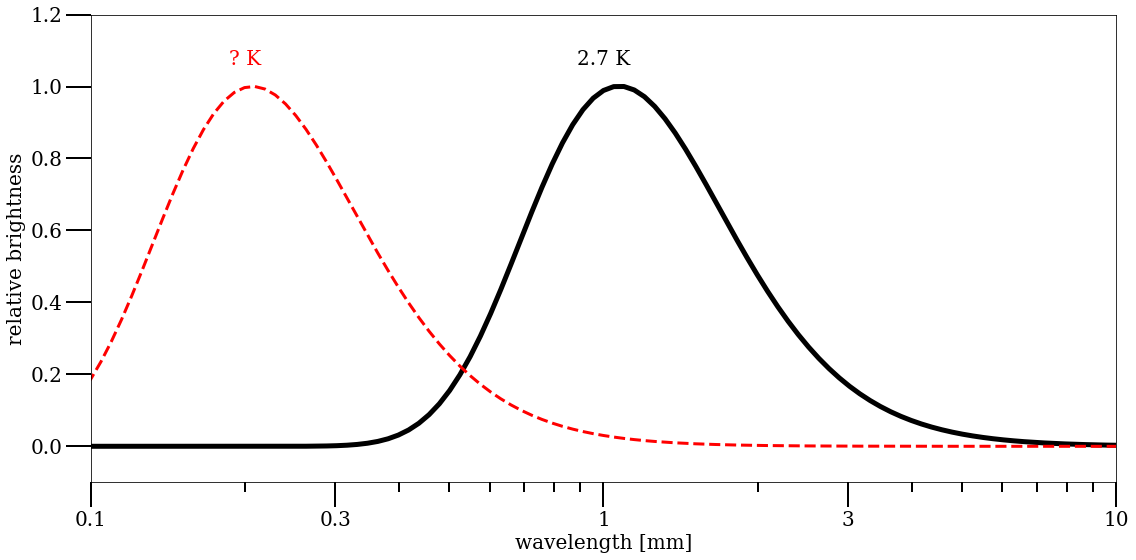

In [43]:
###################
##
##  generate blackbody spectra of arbitrary objects

lambdas = (10 ** np.arange(2,8,0.02)) * 1E-9
print('wavelengths: ', np.min(lambdas), np.max(lambdas))

obj1 = planck_lam(1,lambdas, 2.7)
obj2 = planck_lam(1,lambdas, 1)
obj3 = planck_lam(1,lambdas, 14)
obj4 = planck_lam(1,lambdas, 2.7)
obj5 = planck_lam(1,lambdas, 3E-1)

fig = plt.figure(figsize=(16,8))
plt.plot(lambdas * 1E3, 1 * obj1 / np.max(obj1), color='black',linewidth=5, linestyle='-', label='Early universe, 3,000 K')
plt.annotate(r'2.7 K',xy=(1, 1.05), color='black', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
#plt.plot(lambdas * 1E3, 1 * obj2 / np.max(obj2), color='red',linewidth=3, linestyle='--', label='Early universe, 3,000 K')
#plt.annotate(r'? K',xy=(3, 1.05), color='red', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.plot(lambdas * 1E3, 1 * obj3 / np.max(obj3), color='red',linewidth=3, linestyle='--', label='Early universe, 3,000 K')
plt.annotate(r'? K',xy=(0.2, 1.05), color='red', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.ylabel(r'relative brightness', fontsize=20)
plt.xlabel(r'wavelength [mm]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20, length=25, width=2)
plt.tick_params(axis='both', which='minor', labelsize=10, length=10, width=2)
plt.xlim(0.1, 10)
plt.ylim(-0.1,1.2)
plt.xscale('log')
xticks = np.array([1E-1, 3E-1, 1E0, 3E0, 1E1])
plt.xticks(xticks, ('0.1', '0.3', '1', '3', '10'), rotation=0)
plt.tight_layout()
#draw_color_key()
#legend = plt.legend(loc='upper right', shadow=True, fontsize=20)
#plt.savefig("thermal_spectra_compare_2p7K_1K.jpg") #save as jpg
plt.savefig("thermal_spectra_compare_2p7K_14K.jpg") #save as jpg


wavelengths:  1.0000000000000001e-07 0.09549925860214488


<ipython-input-3-7c9d95b4b398>:6: RuntimeWarning: overflow encountered in exp
  return A*2*h*c**2 / lambdas**5 / (np.exp((h*c) / (lambdas * k * T)) - 1.0)


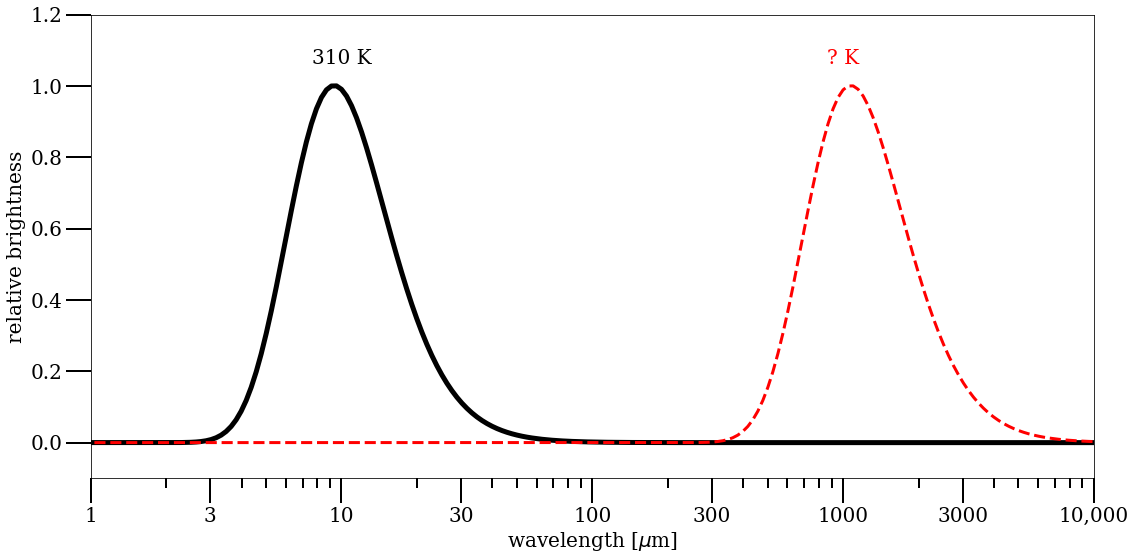

In [45]:
###################
##
##  generate blackbody spectra of arbitrary objects

lambdas = (10 ** np.arange(2,8,0.02)) * 1E-9
print('wavelengths: ', np.min(lambdas), np.max(lambdas))

obj1 = planck_lam(1,lambdas, 310)
obj2 = planck_lam(1,lambdas, 2.7)
obj3 = planck_lam(1,lambdas, 14)
obj4 = planck_lam(1,lambdas, 2.7)
obj5 = planck_lam(1,lambdas, 3E-1)

fig = plt.figure(figsize=(16,8))
plt.plot(lambdas * 1E6, 1 * obj1 / np.max(obj1), color='black',linewidth=5, linestyle='-', label='Early universe, 3,000 K')
plt.annotate(r'310 K',xy=(10, 1.05), color='black', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.plot(lambdas * 1E6, 1 * obj2 / np.max(obj2), color='red',linewidth=3, linestyle='--', label='Early universe, 3,000 K')
plt.annotate(r'? K',xy=(1000, 1.05), color='red', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
#plt.plot(lambdas * 1E3, 1 * obj3 / np.max(obj3), color='red',linewidth=3, linestyle='--', label='Early universe, 3,000 K')
#plt.annotate(r'? K',xy=(0.2, 1.05), color='red', xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='bottom', rotation = 0)
plt.ylabel(r'relative brightness', fontsize=20)
plt.xlabel(r'wavelength [$\mu$m]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20, length=25, width=2)
plt.tick_params(axis='both', which='minor', labelsize=10, length=10, width=2)
plt.xlim(1, 10000)
plt.ylim(-0.1,1.2)
plt.xscale('log')
xticks = np.array([1E0, 3E0, 1E1, 3E1, 1E2, 3E2, 1E3, 3E3, 1E4])
plt.xticks(xticks, ('1', '3', '10', '30', '100', '300', '1000', '3000', '10,000'), rotation=0)
plt.tight_layout()
#draw_color_key()
#legend = plt.legend(loc='upper right', shadow=True, fontsize=20)
#plt.savefig("thermal_spectra_compare_2p7K_1K.jpg") #save as jpg
plt.savefig("thermal_spectra_compare_300K_3K.jpg") #save as jpg
